# Finite-Shot Neural Decoding for Superdense Coding

Reproduces the superdense-coding results of the manuscript (Table 1, Fig. 3).

Three decoders are compared against number of measurement shots:
1. **Majority vote** over the finite-shot counts (weak fixed rule).
2. **Channel-aware maximum-likelihood (ML) decoder** using the known measurement model (non-neural, training-free).
3. **Learned decoder** (small feed-forward network on empirical frequencies).

All results are means over independent seeds with 95% confidence intervals. The learned decoder beats majority vote but only *matches* the ML decoder.

In [1]:
import numpy as np, torch, torch.nn as nn

I=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex); Z=np.array([[1,0],[0,-1]],dtype=complex)
H=(1/np.sqrt(2))*np.array([[1,1],[1,-1]],dtype=complex)
CNOT=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=complex)
bell=(1/np.sqrt(2))*np.array([1,0,0,1],dtype=complex)
gates={0:I,1:X,2:Z,3:X@Z}  # messages 00,01,10,11

# Asymmetric readout confusion matrix (Eq. 5), biased toward outcome |00>
Cm=np.array([[0.92,0.05,0.05,0.00],
             [0.10,0.85,0.00,0.05],
             [0.10,0.00,0.85,0.05],
             [0.00,0.08,0.08,0.84]])


In [2]:
def outcome_probs(msg, pz, px):
    g=gates[msg]; enc=np.kron(g,I)@bell; rho=np.outer(enc,enc.conj())
    # biased Pauli channel on Alice's qubit (Eq. 4): more phase (Z) than bit (X), no Y
    K=[np.sqrt(1-pz-px)*I, np.sqrt(pz)*Z, np.sqrt(px)*X]
    rho=sum(np.kron(k,I)@rho@np.kron(k,I).conj().T for k in K)
    U=np.kron(H,I)@CNOT; rho=U@rho@U.conj().T
    pr=np.clip(np.real(np.diag(rho)),0,None)
    pr=Cm.T@pr; pr=np.clip(pr,0,None); pr/=pr.sum()
    return pr

def make_dataset(N, shots, rng):
    msgs=rng.integers(0,4,N)
    pz=rng.uniform(0.05,0.35,N); px=rng.uniform(0.0,0.10,N)
    counts=np.zeros((N,4),np.float32)
    for i in range(N):
        pr=outcome_probs(msgs[i],pz[i],px[i])
        draws=rng.choice(4,size=shots,p=pr)
        for d in draws: counts[i,d]+=1
    return msgs, counts/np.maximum(shots,1), counts

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(4,128),nn.ReLU(),
                               nn.Linear(128,128),nn.ReLU(),nn.Linear(128,4))
    def forward(self,x): return self.net(x)

# ML templates at mid-range noise (decoder does NOT see per-sample p)
def ml_templates():
    pz,px=0.20,0.05
    return np.stack([outcome_probs(m,pz,px) for m in range(4)])


In [3]:
def one_run(shots, seed, N=9000, epochs=1000):
    rng=np.random.default_rng(seed); torch.manual_seed(seed)
    msgs,freqs,counts=make_dataset(N,shots,rng)
    ntr=7000
    Xtr,Ytr=torch.tensor(freqs[:ntr].astype(np.float32)),torch.tensor(msgs[:ntr].astype(np.int64))
    Xte=freqs[ntr:]; Yte=msgs[ntr:]; counts_te=counts[ntr:]
    acc_maj=(np.argmax(counts_te,1)==Yte).mean()
    logT=np.log(np.clip(ml_templates(),1e-9,None))
    acc_ml=(np.argmax(counts_te@logT.T,1)==Yte).mean()
    m=Decoder(); opt=torch.optim.Adam(m.parameters(),2e-3); lf=nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad(); lf(m(Xtr),Ytr).backward(); opt.step()
    with torch.no_grad(): pred=m(torch.tensor(Xte.astype(np.float32))).argmax(1).numpy()
    return acc_maj, acc_ml, (pred==Yte).mean()

def ci(vals):
    a=np.array(vals); return a.mean(), 1.96*a.std(ddof=1)/np.sqrt(len(a))

SEEDS=[4,5,6]
SHOTS=[1,5,10,20,50,100]
rows=[]
print(f"{'shots':>5} | {'majority':>15} | {'ML decoder':>15} | {'learned':>15}")
for s in SHOTS:
    mj,ml,nn_=zip(*[one_run(s,sd) for sd in SEEDS])
    (mm,mh),(lm,lh),(nm,nh)=ci(mj),ci(ml),ci(nn_)
    rows.append((s,mm,mh,lm,lh,nm,nh))
    print(f"{s:5d} | {mm:6.3f} +/- {mh:5.3f} | {lm:6.3f} +/- {lh:5.3f} | {nm:6.3f} +/- {nh:5.3f}")


shots |        majority |      ML decoder |         learned


    1 |  0.666 +/- 0.007 |  0.666 +/- 0.007 |  0.666 +/- 0.007


    5 |  0.828 +/- 0.005 |  0.880 +/- 0.005 |  0.880 +/- 0.003


   10 |  0.905 +/- 0.007 |  0.940 +/- 0.006 |  0.939 +/- 0.006


   20 |  0.956 +/- 0.004 |  0.976 +/- 0.002 |  0.977 +/- 0.003


   50 |  0.991 +/- 0.002 |  0.998 +/- 0.002 |  0.998 +/- 0.001


  100 |  0.998 +/- 0.001 |  1.000 +/- 0.000 |  1.000 +/- 0.000


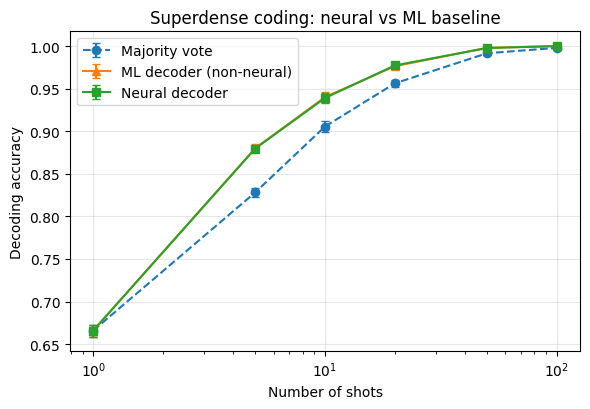

In [4]:
import matplotlib.pyplot as plt
rows=np.array(rows)
s=rows[:,0]
plt.figure(figsize=(6,4.2))
plt.errorbar(s,rows[:,1],yerr=rows[:,2],fmt='o--',capsize=3,label='Majority vote')
plt.errorbar(s,rows[:,3],yerr=rows[:,4],fmt='^-',capsize=3,label='ML decoder (non-neural)')
plt.errorbar(s,rows[:,5],yerr=rows[:,6],fmt='s-',capsize=3,label='Neural decoder')
plt.xscale('log'); plt.xlabel('Number of shots'); plt.ylabel('Decoding accuracy')
plt.title('Superdense coding: neural vs ML baseline'); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig('sdc_baselines.png',dpi=200); plt.show()


**Result.** The learned decoder beats majority vote but is statistically indistinguishable from the channel-aware maximum-likelihood decoder at every shot count. The network learns to approximate the optimal decoder rather than to exceed it.